# Assignment 1
Leong Chii Yen (DSC22092678)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Part a) Data Preprocessing

# Load Dataset

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv(r"marketing_campaign.csv", sep="\t")
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0


Inspect Column Types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

We have 3 object data type and 25 numeric columns (float/numeric)

ID is an identifier, not a feature

From df.info(), Dt_Customer shows the date of customer's enrollment with the company, the current datatype 'object' is inappropriate, we need to change to datetime.

# Check Missing Values

In [13]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

The **Income** column has 24 missing values out of 2,240 rows, which is about 24/2240 × 100 = 1.1% of the data.

The rest of the columns do not have any missing values.

# Check for duplicates

In [16]:
df.duplicated().sum()

0

In [17]:
df['ID'].duplicated().sum() 

0

There are no duplicate rows and each ID appears only once.

# Check for outliers and Unusual entries

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [21]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

**Potential Outliers**

**Year_Birth** has a minimum of 1893, while the vast majority of customers were born between 1959 and 1977 (IQR range).  
Since `Dt_Customer` indicates enrolment around 2014, a birth year of 1893 would correspond to an age of roughly 121 years, which is not plausible for an active customer. These extremely early birth years are therefore likely data-entry errors rather than valid records.

**Income** reaches a maximum of 666,666, whereas typical incomes fall between 35,303 and 68,522 (IQR), with a mean of about 52,247.  
The value 666,666 is an exceptionally large outlier, far beyond the interquartile range and the realistic income levels in this dataset, so it is treated as an anomalous income value.

The other numerical columns have plausible integer ranges.

**Unusual Entries**

**Z_CostContact** is always 3 and **Z_Revenue** is always 11, indicating that they are constant columns and thus carry no useful information for analysis. df.unique() shows that they have only one unique value. 

In [23]:
inc = df['Income']
Q1, Q3 = inc.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

(inc < lower_bound).sum(), (inc > upper_bound).sum(), inc.max()


(0, 8, 666666.0)

# Data Cleaning

In [25]:
df_clean = df.copy()

1. Correct Data Type

In [27]:
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format="%d-%m-%Y")

In [28]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

Converted Dt_Customer from object to datetime to correctly represent customer enrollment dates.

2. Remove unnecessary feature

In [31]:
df_clean = df_clean.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])

In [32]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2240 non-null   int64         
 1   Education            2240 non-null   object        
 2   Marital_Status       2240 non-null   object        
 3   Income               2216 non-null   float64       
 4   Kidhome              2240 non-null   int64         
 5   Teenhome             2240 non-null   int64         
 6   Dt_Customer          2240 non-null   datetime64[ns]
 7   Recency              2240 non-null   int64         
 8   MntWines             2240 non-null   int64         
 9   MntFruits            2240 non-null   int64         
 10  MntMeatProducts      2240 non-null   int64         
 11  MntFishProducts      2240 non-null   int64         
 12  MntSweetProducts     2240 non-null   int64         
 13  MntGoldProds         2240 non-nul

Dropped ID, which is just an identifier, and constant columns Z_CostContact and Z_Revenue, which do not contribute any variance.

3. Handle missing values

In [35]:
df_clean = df_clean.dropna(subset=["Income"]).copy()

In [36]:
df_clean.isnull().sum()

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

I chose to drop rows with missing Income because they make up only about 1% of the data, so removing them minimally affects the sample.

4. Handle Outliers <br> 
a) Income Column

In [39]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_mask = (df['Income'] < lower) | (df['Income'] > upper)
outlier_values = df.loc[outliers_mask, 'Income']
print(outlier_values)

164     157243.0
617     162397.0
655     153924.0
687     160803.0
1300    157733.0
1653    157146.0
2132    156924.0
2233    666666.0
Name: Income, dtype: float64


We detect 8 extreme high-income values using IQR rule, which will be treated as outliers

An inspection of the Income variable reveals a single extreme value of 666,666, which is clearly inconsistent with the rest of the distribution and is treated as a data-entry error and removed. The other outlying values, which lie roughly between 153,000 and 162,000, remain in the dataset. Although they sit above the IQR upper bound, they are still believable as very high-income households and are therefore kept to preserve the high-income customer segment.

In [42]:
df_clean[df_clean['Income'] == 666666]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
2233,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,0


In [43]:
df_clean = df_clean[df_clean['Income'] != 666666]

In [44]:
df_clean[df_clean['Income'] == 666666]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response


666,666 value is now removed. 

b) Year_Birth Column

In [47]:
enrol_year = df_clean['Dt_Customer'].dt.year.max()

max_age = 100   
min_age = 18   

year_min = enrol_year - max_age   
year_max = enrol_year - min_age   

print("Reference enrolment year:", enrol_year)
print("Valid birth-year range:", year_min, "to", year_max)

Reference enrolment year: 2014
Valid birth-year range: 1914 to 1996


In [48]:
valid_birth_mask = (
    (df_clean['Year_Birth'] >= year_min) &
    (df_clean['Year_Birth'] <= year_max)
)
df_clean = df_clean[valid_birth_mask]

# Check new shape
print("Updated dataframe shape:", df_clean.shape)   

Updated dataframe shape: (2212, 26)


For **Year_Birth,** a simple domain rule was applied: only customers aged between 18 and 100 at the time of enrolment are considered valid. Using the latest Dt_Customer year (around 2014) as a reference, this means birth years earlier than 1914 fall outside the valid range; values such as 1893 are therefore treated as data-entry errors and removed. After filtering on this age range, the cleaned dataframe contains 2,212 observations and 26 variables.

# Feature Engineering

a) Recoding the Marital_Status Column

In [52]:
df_clean['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    571
Single      470
Divorced    231
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

The Marital_Status variable is transformed into a binary indicator that reflects whether the customer has a partner:

1. Partnered: Married or living Together
2. NotPartnered: Single, Divorced, Widow, Alone, Absurd, YOLO

For analysing spending and marketing response, the critical distinction is whether someone potentially shares a household and financial decisions, rather than the specific marital label.

In [54]:
partnered_labels = {"Married", "Together"}

df_clean["Is_Partnered"] = df_clean["Marital_Status"].apply(
    lambda s: "Partnered" if s in partnered_labels else "NotPartnered"
)

In [55]:
print(df_clean["Is_Partnered"].value_counts())

Is_Partnered
Partnered       1428
NotPartnered     784
Name: count, dtype: int64


b) Recoding the Education Column

In [57]:
df_clean['Education'].value_counts()

Education
Graduation    1115
PhD            480
Master         365
2n Cycle       198
Basic           54
Name: count, dtype: int64

To reduce dimensionality and avoid very sparse categories, the original Education labels are collapsed into three broader levels:
1. Low_Level (Basic)
2. Bachelors (Graduation)
3. Postgraduate (Master, 2n Cycle, PhD)

This preserves meaningful differences in educational attainment while simplifying the variable.

In [59]:
def recode_education(x):
    if x == "Basic":
        return "Low_Level"
    elif x == "Graduation":
        return "Bachelors"
    else:  # "Master", "2n Cycle", "PhD"
        return "Postgraduate"

df_clean["Education_Level"] = df_clean["Education"].apply(recode_education)

In [60]:
print(df_clean["Education_Level"].value_counts())

Education_Level
Bachelors       1115
Postgraduate    1043
Low_Level         54
Name: count, dtype: int64


c) Create Tenure_days Column

We derive a Tenure_days variable that captures how long each individual has been a customer by taking the difference in days between the latest enrolment date (Dt_Customer) and each person’s own enrolment date. This provides a measure of relationship length with the company, which is useful for analysing loyalty patterns (e.g. spending or campaign response by tenure) and for grouping customers by how long they have been active.

In [63]:
latest_enrol_date = df_clean["Dt_Customer"].max()

df_clean["Tenure_days"] = (latest_enrol_date - df_clean["Dt_Customer"]).dt.days

In [64]:
# Check a few rows
df_clean[["Dt_Customer", "Tenure_days"]].head()

,Dt_Customer,Tenure_days
0,2012-09-04,663
1,2014-03-08,113
2,2013-08-21,312
3,2014-02-10,139
4,2014-01-19,161


d) Create an Age Column

Instead of working directly with Year_Birth, we derive an Age variable by subtracting the birth year from the latest customer enrolment year in Dt_Customer. This produces a more intuitive measure for analysis (e.g. age distributions and age-based segments) and provides a consistent demographic scale for clustering.

In [67]:
enrol_year = df_clean["Dt_Customer"].dt.year.max()

# Compute Age from Year_Birth
df_clean["Age"] = enrol_year - df_clean["Year_Birth"]

In [68]:
# original birth year vs new Age column
df_clean[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,57
1,1954,60
2,1965,49
3,1984,30
4,1981,33


e) Create TotalMntSpent Column

TotalMntSpent is defined as the sum of all product spending variables (MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds) for each customer over the past two years. This combined measure captures overall monetary value per customer, making it easier to analyse spending patterns and to segment customers into low, medium, and high spenders while still reflecting their full purchase behaviour.

In [71]:
spend_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df_clean["TotalMntSpent"] = df_clean[spend_cols].sum(axis=1)

In [72]:
# original spend columns vs the new TotalMntSpent
df_clean[["MntWines", "MntFruits", "MntMeatProducts",
          "MntFishProducts", "MntSweetProducts",
          "MntGoldProds", "TotalMntSpent"]].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,TotalMntSpent
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


f) Create Age_group Column

For easier interpretation in plots, the continuous Age variable is also categorised into three bands: Young Adult (under 30), Adult (30–45), and Senior Adult (over 45). The original numeric Age feature is still kept for modelling and clustering.

In [75]:
bins = [0, 30, 45, df_clean["Age"].max()]
labels = ["Young Adult (<30)", "Adult (30-45)", "Senior Adult (>45)"]

df_clean["Age_group"] = pd.cut(df_clean["Age"], bins=bins, labels=labels, right=False)

In [76]:
# Check a few rows
df_clean[["Age", "Age_group"]].head()

,Age,Age_group
0,57,Senior Adult (>45)
1,60,Senior Adult (>45)
2,49,Senior Adult (>45)
3,30,Adult (30-45)
4,33,Adult (30-45)


# After feature Engineering

In [78]:
df_clean.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Is_Partnered,Education_Level,Tenure_days,Age,TotalMntSpent,Age_group
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,NotPartnered,Bachelors,663,57,1617,Senior Adult (>45)
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,NotPartnered,Bachelors,113,60,27,Senior Adult (>45)
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,Partnered,Bachelors,312,49,776,Senior Adult (>45)
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,Partnered,Bachelors,139,30,53,Adult (30-45)
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,Partnered,Postgraduate,161,33,422,Adult (30-45)


In [79]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2212 non-null   int64         
 1   Education            2212 non-null   object        
 2   Marital_Status       2212 non-null   object        
 3   Income               2212 non-null   float64       
 4   Kidhome              2212 non-null   int64         
 5   Teenhome             2212 non-null   int64         
 6   Dt_Customer          2212 non-null   datetime64[ns]
 7   Recency              2212 non-null   int64         
 8   MntWines             2212 non-null   int64         
 9   MntFruits            2212 non-null   int64         
 10  MntMeatProducts      2212 non-null   int64         
 11  MntFishProducts      2212 non-null   int64         
 12  MntSweetProducts     2212 non-null   int64         
 13  MntGoldProds         2212 non-null   i

Now we have a total of 32 columns and no missing values.

# Part b) Exploratory Data Analysis

In [82]:
sns.set(style="whitegrid")

1) Age distribution (demographics)

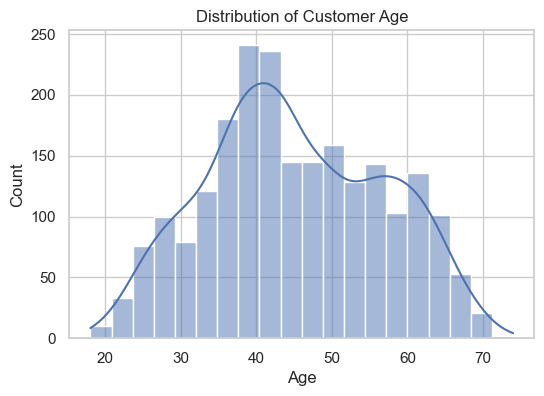

In [84]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean["Age"], bins=20, kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Most customers are between about 30 and 60 years old and peaks around late 30s to early 40s with relatively few very young or very old customers.

2) Income distribution

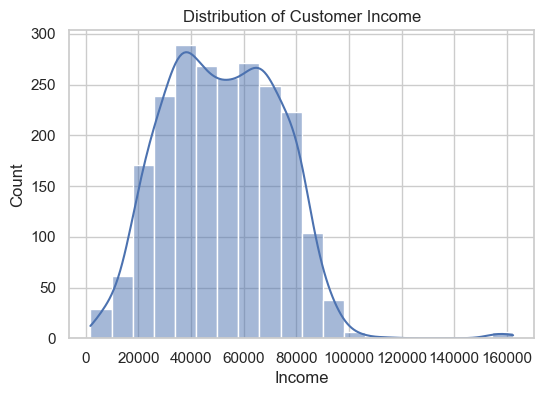

In [87]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean["Income"], bins=20, kde=True)
plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Income is right-skewed as many customers have moderate incomes, while a smaller group earns very high incomes. The incomes are centered rougly in the 35,000 to 70,000 range, indicating a right-skewed distribution. 

3) Total spending distribution (TotalMntSpent)

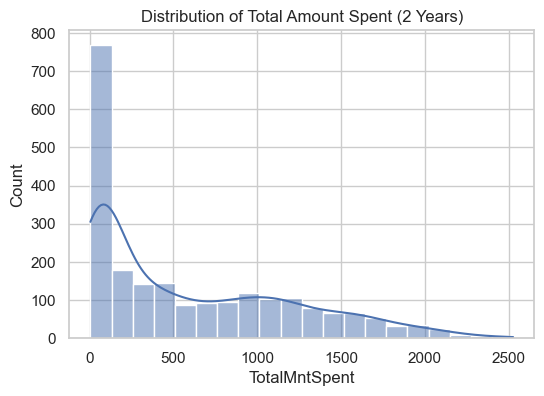

In [90]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean["TotalMntSpent"], bins=20, kde=True)
plt.title("Distribution of Total Amount Spent (2 Years)")
plt.xlabel("TotalMntSpent")
plt.ylabel("Count")
plt.show()

Most customers spend relatively little over two years, but there is a tail of high-spending customers. It shows a right-skewed spending distribution. 

4) Relationship: Income vs Total spending

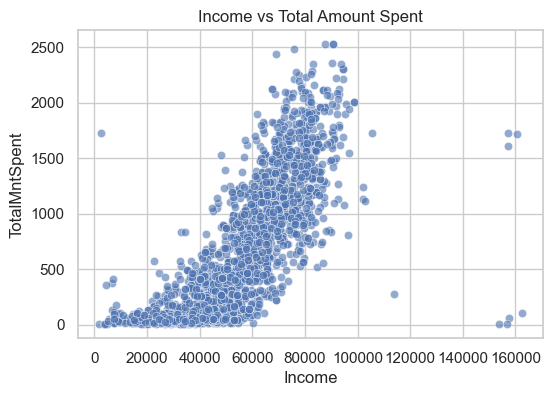

In [93]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x="Income", y="TotalMntSpent", alpha=0.6)
plt.title("Income vs Total Amount Spent")
plt.xlabel("Income")
plt.ylabel("TotalMntSpent")
plt.show()

There is a weak positive trend, higher-income customers tend to spend more overall, but with a lot of variability.

5) Spending by Age group

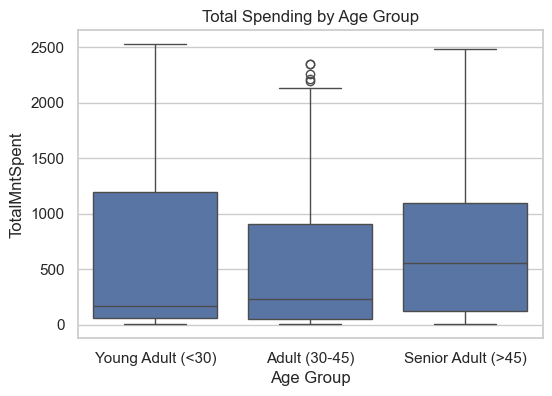

In [96]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x="Age_group", y="TotalMntSpent")
plt.title("Total Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("TotalMntSpent")
plt.show()

Adult (30–45) and Senior (>45) groups generally spend more than Young Adults (<30), especially in the upper quartiles.

6) Campaign response by partnership status

Here we use Response (0/1) and the Is_Partnered variable that is created.

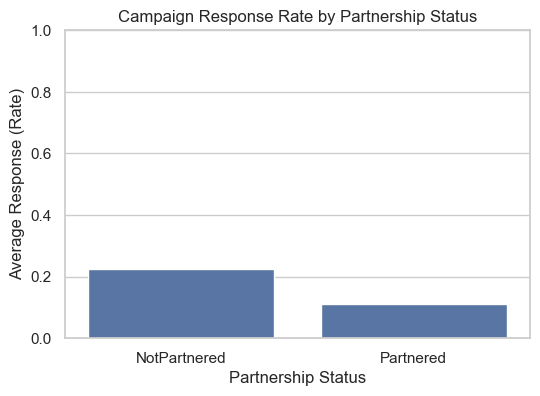

In [100]:
response_by_partner = df_clean.groupby("Is_Partnered")["Response"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=response_by_partner, x="Is_Partnered", y="Response")
plt.title("Campaign Response Rate by Partnership Status")
plt.xlabel("Partnership Status")
plt.ylabel("Average Response (Rate)")
plt.ylim(0, 1)
plt.show()

Partnered customers show a slightly lower response rate compared with non-partnered customers, indicating that household structure may influence campaign success. Customers who are single, divorced, widowed, or otherwise not living with a partner respond better to the campaign, so they are an important group to target in future promotions.

7) Campaign response by education level 

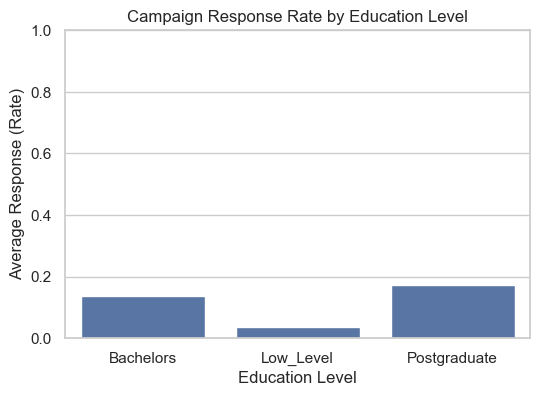

In [103]:
response_by_edu = df_clean.groupby("Education_Level")["Response"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=response_by_edu, x="Education_Level", y="Response")
plt.title("Campaign Response Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Response (Rate)")
plt.ylim(0, 1)
plt.show()

Response rates differ slightly by education level, with Postgraduate reacting more positively to campaigns than others.
This pattern shows that customers with higher education levels tend to respond more to the marketing campaign, which may mean that the current message, channels, or offers work especially well for these better-educated segments.

# Part c) Choose features and scale them

1. Choose features and scale them

We’ll cluster on a mix of demographics and spending:

- Age
- Income
- TotalMntSpent
- Kidhome
- Teenhome
- Recency
- Tenure_days
- Is_Partnered_num (1 = Partnered, 0 = NotPartnered)

In [108]:
from sklearn.preprocessing import StandardScaler

df_clean["Is_Partnered_num"] = df_clean["Is_Partnered"].map({
    "Partnered": 1,
    "NotPartnered": 0
})

features = [
    "Age",
    "Income",
    "TotalMntSpent",
    "Kidhome",
    "Teenhome",
    "Recency",
    "Tenure_days",
    "Is_Partnered_num"
]

X = df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. Elbow method to pick number of clusters

We compute the inertia (within-cluster sum of squares) for different k and plot.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

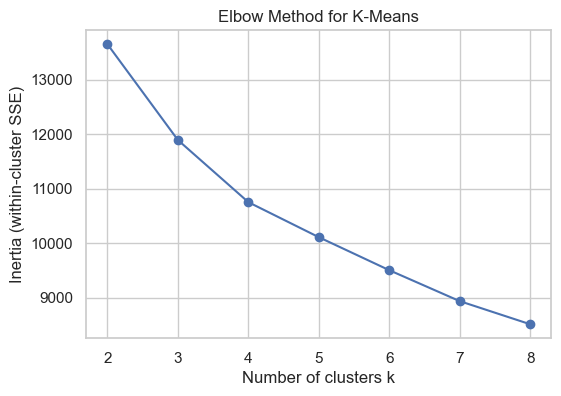

In [111]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 9)   

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method for K-Means")
plt.show()

The elbow plot shows a clear bend around k = 4, so we choose 4 clusters as a good trade-off between simplicity and fit.

3. Fit final K-Means model with k = 4

In [114]:
k_opt = 4  
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)

df_clean["Cluster"] = kmeans.fit_predict(X_scaled)
# check cluster sizes
df_clean["Cluster"].value_counts()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Cluster
2    678
1    610
3    522
0    402
Name: count, dtype: int64

The dataset is split into four clusters with sizes roughly between 400 and 700 customers, so no single cluster completely dominates.

4. Summarise clusters by key features

In [117]:
cluster_summary = (
    df_clean.groupby("Cluster")[["Age", "Income", "TotalMntSpent",
                         "Recency", "Tenure_days",
                         "Kidhome", "Teenhome",
                         "Is_Partnered_num", "Response"]].mean().round(1)
)

cluster_summary.T

Cluster,0,1,2,3
Age,48.6,36.0,51.0,45.3
Income,42782.6,30565.8,56893.2,77616.0
TotalMntSpent,178.9,138.4,670.5,1402.8
Recency,49.2,48.9,48.7,49.5
Tenure_days,332.6,346.6,374.7,351.0
Kidhome,1.1,0.8,0.0,0.0
Teenhome,1.0,0.0,1.0,0.0
Is_Partnered_num,0.6,0.7,0.7,0.6
Response,0.1,0.1,0.1,0.3


Interpretation

1. Cluster 0 – Older families with kids, low spending
- Average age = 49, income around 43k.
- Low total spending (178.9).
- Often have both kids and teenagers at home (Kidhome = 1.1, Teenhome = 1.0).
- Response rate is low (10%).

2. Cluster 1 – Young, low-income households, very low spending
- Youngest group (age = 36), the lowest income among all clusters (around 31k).
- Lowest total spending (138.4).
- Some small children, almost no teenagers.
- Mostly partnered (Is_Partnered = 0.7), response rate still low (10%).

3. Cluster 2 – Older, higher-income families with teenagers
- Oldest group (age = 51) with higher income (around 57k).
- High spending (TotalMntSpent about 670).
- No small kids but about one teenager per household.
- Response rate similar to other clusters (10%).

4. Cluster 3 – Wealthy, child-free heavy spenders (most responsive)
- Age around 45, highest income (about 77k).
- Very high spending (TotalMntSpent = 1402.8).
- Almost no children or teenagers at home.
- Highest campaign response rate (30%), so this is the most attractive target segment.

5. Visualisations of clusters

a) Income by cluster

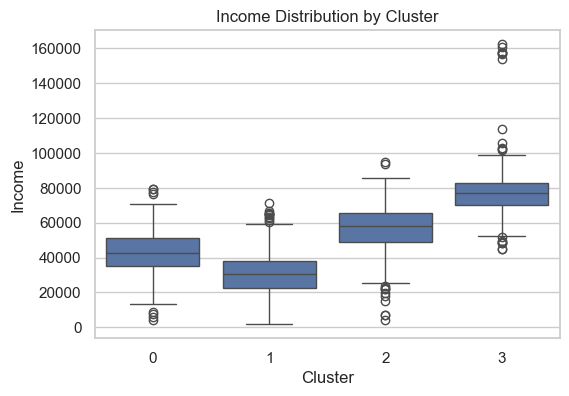

In [122]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x="Cluster", y="Income")
plt.title("Income Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Income")
plt.show()

b) Total spending by cluster

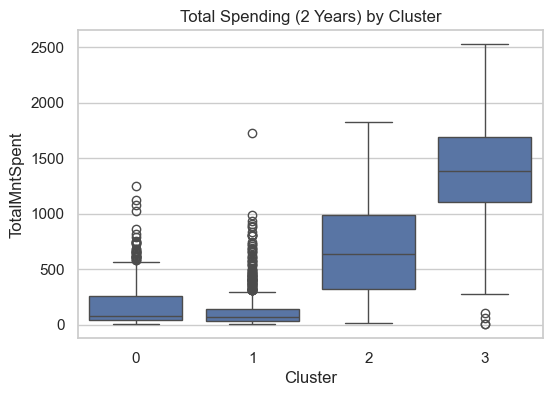

In [124]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x="Cluster", y="TotalMntSpent")
plt.title("Total Spending (2 Years) by Cluster")
plt.xlabel("Cluster")
plt.ylabel("TotalMntSpent")
plt.show()

c) Response rate by cluster

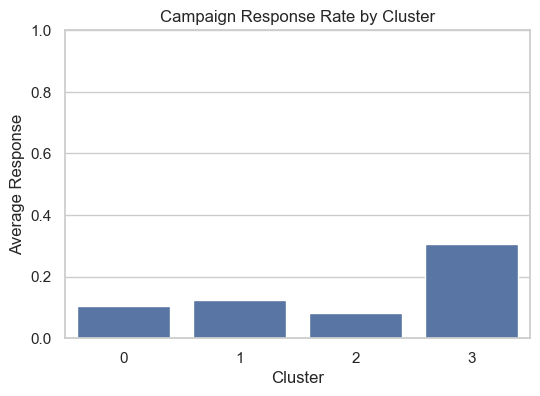

In [126]:
resp_by_cluster = (
    df_clean.groupby("Cluster")["Response"].mean().reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(data=resp_by_cluster, x="Cluster", y="Response")
plt.title("Campaign Response Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Response")
plt.ylim(0, 1)
plt.show()

- Clusters 0 and 1 both have relatively low income and low total spending, with Cluster 1 being the lowest overall.
- Cluster 2 has clearly higher income and much higher total spending than clusters 0 and 1, so it represents a more wealthy, higher-spending segment.
- Cluster 3 stands out with the highest income, the highest total spending, and the highest campaign response rate, making it the most valuable and most responsive customer group.

In [128]:
df_clean.to_csv("marketing_campaign_clustered.csv", index=False)

The final dataset with cluster labels was exported as marketing_campaign_clustered.csv for further analysis and reporting.